# 한국어 빈도 분석과 워드클라우드

워드클라우드는 자주 등장한 단어를 크게 보여주는 **빈도 시각화**이다. 긴 문서의 반복 어휘와 전처리 결과를 빠르게 살펴볼 때 사용하지만, 단어의 통계적 중요도·감정·문맥을 증명하지는 않는다.


## 워드클라우드의 핵심 개념

워드클라우드는 빈도를 빠르게 훑는 도구이며, 단어의 위치와 색에는 기본적으로 분석 의미가 없다.

- **빈도 시각화**: 단어 출현 횟수를 글자 크기나 막대 길이로 표현하는 방법
- **워드클라우드(Word Cloud)**: 자주 등장한 단어일수록 크게 배치하는 빈도 시각화
- **형태소 분석**: 문장을 의미와 문법 기능을 가진 단위로 나누는 과정
- **불용어(Stopword)**: 현재 분석 목적에서 정보가 적어 제외하는 단어
- **마스크(Mask)**: 단어 배치 영역과 빈 영역을 구분하는 2차원 배열

불용어를 지나치게 제거하면 중요한 주제가 사라질 수 있다. 워드클라우드에서 단어의 상대적 출현 빈도는 읽을 수 있지만, TF-IDF 중요도·통계적 유의성·감정·단어 사이의 문맥은 해석하지 않는다.


## 패키지 준비

텍스트 처리, 빈도 계산과 시각화에 필요한 도구를 불러온다.

- **Okt**: 한국어 텍스트를 형태소 단위로 분석하는 KoNLPy 분석기
- **Counter**: 각 단어의 등장 횟수를 세어 저장하는 컬렉션 클래스
- **WordCloud**: 단어별 빈도를 글자 크기로 표현하는 워드클라우드 생성 클래스
- **NumPy**: 원형 마스크를 2차원 배열로 만드는 수치 연산 라이브러리
- **pandas**: CSV 데이터를 표 형태의 `DataFrame`으로 다루는 라이브러리
- **Matplotlib**: 빈도 막대그래프와 워드클라우드 이미지를 표시하는 시각화 라이브러리

pandas로 읽은 문장을 Okt와 Counter로 집계하고, 그 결과를 WordCloud와 Matplotlib으로 시각화한다.


In [1]:

# %pip install -q gdown konlpy wordcloud

import re
from collections import Counter
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from konlpy.tag import Okt
from matplotlib import font_manager
from wordcloud import WordCloud


Note: you may need to restart the kernel to use updated packages.


## 한국어 SMS 데이터 내려받기

공개 Google Drive의 SMS CSV를 노트북과 같은 폴더에 저장한다.

- **Path()**: 운영체제와 관계없이 파일 경로 객체를 만드는 클래스
- **gdown.download()**: Google Drive 파일을 내려받고 저장 경로를 반환하는 함수

데이터 출처: [한국어 SMS 스팸 데이터](https://drive.google.com/file/d/13Rs5KQiFFIM047i0qLS86_GZvoVnmrRk/view?usp=sharing)


In [2]:

file_id = "13Rs5KQiFFIM047i0qLS86_GZvoVnmrRk"
download_url = f"https://drive.google.com/uc?id={file_id}"

dataset_path = Path("ko_sms_spam.csv")
downloaded_path = gdown.download(download_url, str(dataset_path), quiet=False)
print(f"저장 파일: {downloaded_path}")


Downloading...
From: https://drive.google.com/uc?id=13Rs5KQiFFIM047i0qLS86_GZvoVnmrRk
To: /Users/choejiheum/SKN_AI/08_nlp/02_preprocessing/ko_sms_spam.csv
100%|██████████| 33.7M/33.7M [00:01<00:00, 21.8MB/s]


저장 파일: ko_sms_spam.csv


### SMS 데이터 구조 확인

CSV를 표 형태로 읽고 데이터 크기와 열을 확인한다. `SEQ`는 식별자이고 워드클라우드에 사용할 본문은 `CN`이다.

- **pd.read_csv()**: CSV 파일을 읽어 pandas `DataFrame`으로 반환하는 함수
- **DataFrame.shape**: 데이터의 `(행 수, 열 수)`를 제공하는 튜플 속성
- **head()**: 데이터 앞부분을 지정한 행 수만큼 반환하는 메서드


In [3]:

spam_df = pd.read_csv(dataset_path)

print("데이터 크기:", spam_df.shape)
print("열 이름:", spam_df.columns.tolist())
display(spam_df.head())


데이터 크기: (29588, 2)
열 이름: ['SEQ', 'CN']


,SEQ,CN
0,842298,[Web발신]ifg@(광고)[한음대리점 율량점] 류태자 단골고객님ifg@ifg@마지...
1,842299,[Web발신]ifg@(광고)[전자랜드중동점]ifg@최은순 고객님!ifg@전자랜드 *...
2,842300,"제목 : (광고)현대미아점 통합ifg@▶*O,OOO원할인권◀도착ifg@현대미아 설화..."
3,842301,[Web발신]ifg@(광고) 신세계면세점 명동점ifg@ifg@본 문자 수신 고객님께...
4,842302,[Web발신]ifg@(광고) 롯데마트 소중한 집사의 통장을 지켜라! 멍이도 냥이도 ...


### 분석용 코퍼스 정제

앞의 100개 메시지를 하나로 연결한 뒤 URL, `ifg@` 표식과 중복 공백을 제거한다.

- **코퍼스(Corpus)**: 분석 대상으로 모아 둔 텍스트 집합
- **re.sub()**: 정규표현식과 일치하는 문자열을 다른 문자열로 치환하는 함수
- **strip()**: 문자열의 앞뒤 공백을 제거하는 메서드

URL처럼 반복되지만 주제를 설명하지 않는 문자열을 먼저 제거해야 이후 단어 빈도가 메시지 내용에 더 가깝게 계산된다.


In [4]:
messages = spam_df["CN"].head(100).dropna().astype(str)
raw_corpus = "\n".join(messages)

cleaned_corpus = re.sub(r"https?://\S+|ifg@", " ", raw_corpus)
cleaned_corpus = re.sub(r"\s+", " ", cleaned_corpus).strip()

print("사용한 메시지 수:", len(messages))
print("정제 전 문자 수:", len(raw_corpus))
print("정제 후 문자 수:", len(cleaned_corpus))

사용한 메시지 수: 100
정제 전 문자 수: 65627
정제 후 문자 수: 50645


### 불용어 사전 구성

`stopwords-ko.txt`의 일반 불용어와 SMS에서 정보가 적은 단어를 결합한다. 불용어는 분석 목적과 실제 토큰을 보고 조정해야 한다.

- **set**: 중복을 허용하지 않는 집합 자료형
- **집합 합치기(`|`)**: 두 집합의 모든 원소를 중복 없이 결합하는 연산
- **Path.open()**: 지정한 경로의 파일을 열어 읽거나 쓰는 메서드


In [5]:

stopwords_path = Path("stopwords-ko.txt")
with stopwords_path.open(encoding="utf-8") as file:
    file_stopwords = {line.strip() for line in file if line.strip()}

domain_stopwords = {"원", "시", "월", "일", "수", "구", "제", "다", "호", "를", "및", "등", "것"}
stopwords = file_stopwords | domain_stopwords

print("파일 불용어 수:", len(file_stopwords))
print("결합한 불용어 수:", len(stopwords))
print("추가한 도메인 불용어:", sorted(domain_stopwords))


파일 불용어 수: 595
결합한 불용어 수: 600
추가한 도메인 불용어: ['것', '구', '다', '등', '를', '및', '수', '시', '원', '월', '일', '제', '호']


### 명사 추출과 빈도 집계

명사를 추출한 뒤 한 글자 단어와 불용어를 제외하고 출현 빈도를 계산한다.

- **Okt.nouns()**: 한국어 문장에서 명사만 추출해 문자열 목록으로 반환하는 메서드
- **Counter()**: 목록 원소의 등장 횟수를 `{원소: 횟수}` 형태로 집계하는 클래스
- **most_common(n)**: 빈도순 상위 `n`개의 `(원소, 횟수)`를 반환하는 메서드

이 단계에서 만든 명사 빈도는 다음의 빈도표와 최종 워드클라우드가 공통으로 사용하는 기준이다.


In [7]:
okt = Okt()
nouns = okt.nouns(cleaned_corpus)

# 두 글자 이상이며 불용어가 아닌 명사만 남긴다.
filtered_nouns = [
    noun
    for noun in nouns
    if len(noun) > 1 and noun not in stopwords
]

word_counter = Counter(filtered_nouns)
word_counts = dict(word_counter.most_common(100))

print("추출된 명사 수:", len(nouns))
print("필터링 후 명사 수:", len(filtered_nouns))
print("고유 명사 수:", len(word_counter))
print("상위 10개:", word_counter.most_common(10))

추출된 명사 수: 10293
필터링 후 명사 수: 7704
고유 명사 수: 2078
상위 10개: [('증정', 129), ('할인', 125), ('혜택', 114), ('만원', 111), ('고객', 99), ('무료', 88), ('발신', 87), ('구매', 80), ('광고', 79), ('추가', 68)]


### 상위 빈도 막대그래프

워드클라우드만으로는 정확한 횟수를 읽기 어렵다. 상위 15개 단어를 표와 막대그래프로 확인하고 시스템의 `AppleGothic` 글꼴을 사용한다.

- **pd.DataFrame()**: 행과 열로 구성된 표 형태의 데이터를 만드는 클래스
- **font_manager.findfont()**: 지정한 글꼴의 실제 파일 경로를 찾는 함수
- **barh()**: 범주별 수치를 가로 막대그래프로 그리는 메서드

빈도표와 막대그래프는 `증정 129회`, `할인 125회`처럼 정확한 횟수와 순위를 비교하는 도구이다. 워드클라우드는 이 빈도를 상대적 글자 크기로 빠르게 훑는 도구이므로 정확한 차이는 빈도표에서 확인한다.

`font_path`는 워드클라우드가 한글 글리프가 있는 글꼴 파일을 직접 찾도록 한다. 한글을 지원하지 않는 기본 글꼴을 사용하면 단어가 네모 상자나 빈 문자로 렌더링될 수 있다.


 단어  빈도
 증정 129
 할인 125
 혜택 114
 만원 111
 고객  99
 무료  88
 발신  87
 구매  80
 광고  79
 추가  68
이벤트  64
 행사  63
 거부  60
 수신  51
 안내  51


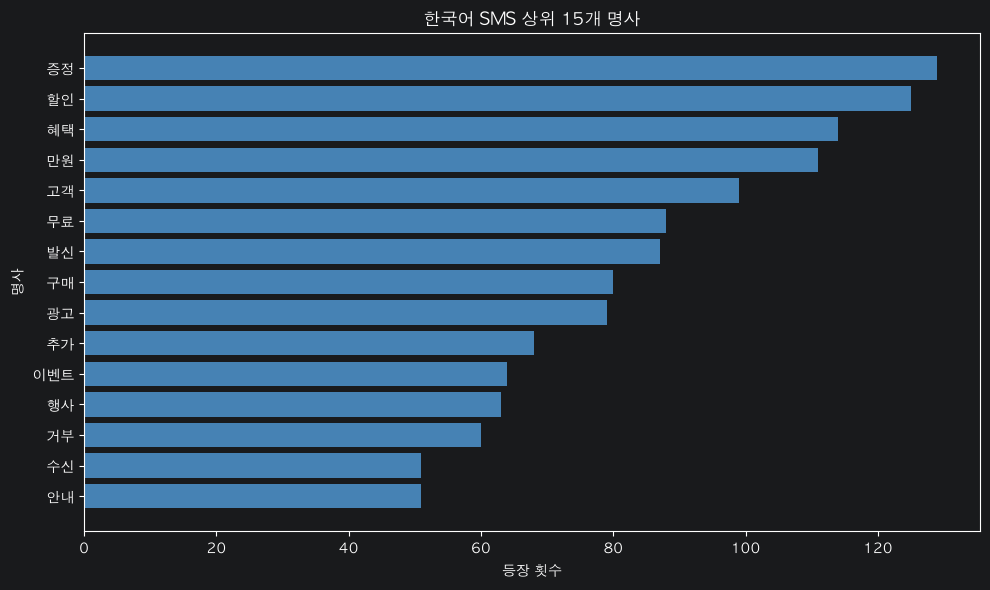

In [10]:
import platform

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager


top_words_df = pd.DataFrame(
    word_counter.most_common(15),
    columns=["단어", "빈도"],
)

print(top_words_df.to_string(index=False))


system_name = platform.system()

if system_name == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
elif system_name == "Darwin":
    font_path = font_manager.findfont(
        "AppleGothic",
        fallback_to_default=False,
    )
else:
    font_path = font_manager.findfont(
        "NanumGothic",
        fallback_to_default=False,
    )


font_name = font_manager.FontProperties(
    fname=font_path,
).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False


plot_df = top_words_df.iloc[::-1]

figure, axis = plt.subplots(figsize=(10, 6))

axis.barh(
    plot_df["단어"],
    plot_df["빈도"],
    color="steelblue",
)

axis.set_title("한국어 SMS 상위 15개 명사")
axis.set_xlabel("등장 횟수")
axis.set_ylabel("명사")

figure.tight_layout()
plt.show()

### 문자열로 워드클라우드 생성

원문 문자열을 직접 전달하면 `WordCloud`가 단어를 나누고 빈도를 계산한다. `stopwords`를 제외하고 연속 단어 묶음은 사용하지 않는다.

- **WordCloud()**: 크기·글꼴·배경색·최대 단어 수를 설정하는 워드클라우드 클래스
- **generate(text)**: 문자열을 토큰화하고 빈도를 계산해 워드클라우드를 생성하는 메서드
- **collocations=False**: 함께 등장한 두 단어를 하나의 구문으로 묶지 않는 설정
- **words_**: 생성 단어와 0~1로 정규화된 상대 빈도를 저장하는 속성

이 결과는 형태소 분석을 거치지 않은 기준선이다. `generate(text)`가 문자열을 자체 규칙으로 나누므로 조사·어미가 붙은 표현이 남을 수 있으며, 뒤에서 Okt로 직접 집계한 명사 빈도 결과와 비교한다.


In [ ]:

raw_wordcloud = WordCloud(
    width=800,
    height=600,
    font_path=font_path,
    background_color="white",
    stopwords=stopwords,
    max_words=100,
    colormap="Blues",
    collocations=False,
    random_state=42,
).generate(cleaned_corpus)

raw_top_words = list(raw_wordcloud.words_.items())[:10]
print("원문 기반 상위 토큰:", raw_top_words)


### 원형 마스크 만들기

800×800 배열에서 원 안쪽은 배치 허용 값 `0`, 바깥은 금지 값 `255`로 만든다. 마스크의 `shape`은 `(높이, 너비)`이다.

- **np.ogrid**: 행·열 좌표를 메모리 효율적인 2차원 격자로 만드는 객체
- **np.full()**: 지정한 `shape`을 하나의 값으로 채운 배열을 만드는 함수
- **np.unique()**: 배열의 고유한 값과 각 값의 개수를 구하는 함수

마스크는 단어의 크기나 순위를 계산하지 않고 워드클라우드가 채워질 모양만 결정한다.


In [ ]:

canvas_size = 800
row_coords, column_coords = np.ogrid[:canvas_size, :canvas_size]
center = (canvas_size - 1) / 2
radius = canvas_size * 0.45

circle_mask = np.full((canvas_size, canvas_size), 255, dtype=np.uint8)
inside_circle = (
    (row_coords - center) ** 2 + (column_coords - center) ** 2
    <= radius ** 2
)
circle_mask[inside_circle] = 0

pixel_values, pixel_counts = np.unique(circle_mask, return_counts=True)
print("마스크 shape:", circle_mask.shape)
print("마스크 dtype:", circle_mask.dtype)
print("픽셀 값과 개수:", list(zip(pixel_values, pixel_counts)))

figure, axis = plt.subplots(figsize=(5, 5))
axis.imshow(circle_mask, cmap="gray")
axis.set_title("원형 워드클라우드 마스크")
axis.axis("off")
plt.show()


### 명사 빈도로 워드클라우드 생성

직접 집계한 명사 빈도와 원형 마스크를 사용해 최종 워드클라우드를 만든다. 마스크는 배치 영역만 바꾸며 단어의 빈도와 순위는 바꾸지 않는다.

- **generate_from_frequencies(frequencies)**: `{단어: 빈도}` 딕셔너리로 워드클라우드를 생성하는 메서드
- **mask**: `0` 영역에는 단어를 배치하고 `255` 영역은 비워 두는 배열 인자
- **random_state**: 같은 입력의 단어 배치를 재현하기 위한 난수 기준값

`generate_from_frequencies(dict)`는 이미 계산한 `{단어: 빈도}`를 그대로 사용해 내부 토큰화를 다시 수행하지 않는다. 한국어에서는 Okt 명사 추출과 불용어 제거 결과를 보존할 수 있으므로 원문 문자열을 전달하는 `generate(text)`보다 분석 기준을 명확하게 통제할 수 있다.


### 두 생성 방식 비교

왼쪽은 원문 문자열, 오른쪽은 전처리한 명사 빈도를 사용한다. 단어 크기의 차이와 오른쪽의 원형 경계를 비교한다.

- **imshow()**: 배열이나 이미지 객체를 좌표축에 표시하는 메서드
- **axis("off")**: 눈금과 축선을 숨기는 메서드

두 그림의 차이는 전처리와 입력 방식의 영향이다. 빈도표의 `129회`와 `125회`는 정확한 횟수이고 워드클라우드의 `1.0`과 `0.969`는 최고 빈도에 대한 상대 크기이므로, 정확한 수치 비교는 표에서 수행한다.

오른쪽의 원형은 마스크가 배치 가능한 픽셀만 제한한 결과이다. 마스크는 단어 순위·빈도·통계적 중요도를 바꾸지 않으며 어느 그림도 문맥이나 감정을 보여주지 않는다.


In [ ]:

figure, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(raw_wordcloud, interpolation="bilinear")
axes[0].set_title("generate(): 원문 문자열 기반")
axes[0].axis("off")

axes[1].imshow(frequency_wordcloud, interpolation="bilinear")
axes[1].set_title("generate_from_frequencies(): 명사 빈도 기반")
axes[1].axis("off")

figure.tight_layout()
plt.show()


### 이미지 저장

명사 빈도 기반 워드클라우드를 현재 노트북 실행 경로의 `ko_sms_spam_wordcloud.png`로 저장한다.

- **to_file(filename)**: 워드클라우드 이미지를 지정한 파일 경로에 저장하는 메서드

출력 메시지의 `저장 파일: ko_sms_spam_wordcloud.png`를 확인하고, 저장된 이미지에는 명사 빈도와 원형 마스크 배치가 반영되었는지 확인한다.


In [ ]:

output_image_path = Path("ko_sms_spam_wordcloud.png")
frequency_wordcloud.to_file(str(output_image_path))
print(f"저장 파일: {output_image_path}")
